In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../data/plots', exist_ok=True)

df = pd.read_csv('../data/csv/cleaned_dataset.csv', low_memory=False)

df['Label'] = df['Label'].astype(str).str.strip()
df['Label'] = df['Label'].replace({
    'Web Attack � Brute Force': 'Web Attack - Brute Force',
    'Web Attack � XSS': 'Web Attack - XSS',
    'Web Attack � Sql Injection': 'Web Attack - Sql Injection'
})

print(f"✓ Yüklendi: {df.shape[0]:,} satır, {df.shape[1]} sütun")

✓ Yüklendi: 495,855 satır, 72 sütun


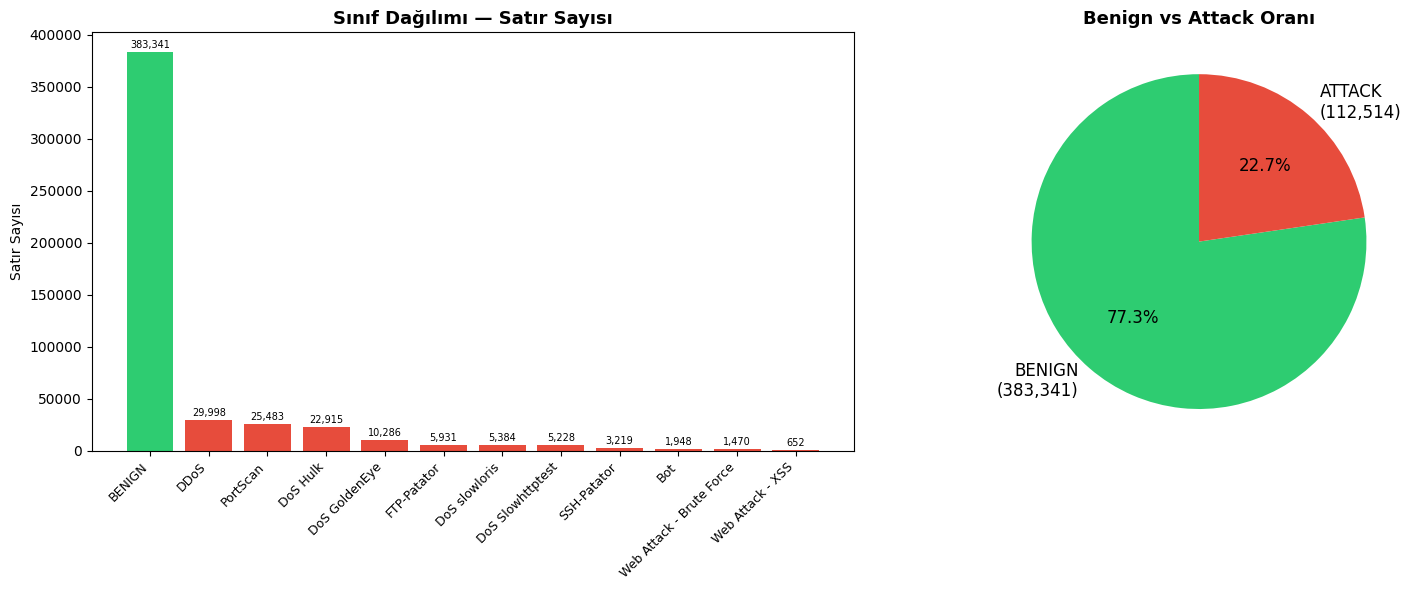

✓ Kaydedildi: ../data/plots/class_distribution.png


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

label_counts = df['Label'].value_counts()

# Sol: Bar chart
colors = ['#2ecc71' if l == 'BENIGN' else '#e74c3c' for l in label_counts.index]
bars = axes[0].bar(range(len(label_counts)), label_counts.values, color=colors)

axes[0].set_xticks(range(len(label_counts)))
axes[0].set_xticklabels(label_counts.index, rotation=45, ha='right', fontsize=9)
axes[0].set_title('Sınıf Dağılımı — Satır Sayısı', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Satır Sayısı')

# Yazı offset (dinamik)
offset = max(label_counts.values) * 0.005
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + offset,
                 f'{val:,}', ha='center', va='bottom', fontsize=7)

# Sağ: Pie chart (Benign vs Attack toplam)
benign_total = label_counts['BENIGN']
attack_total = label_counts.drop('BENIGN').sum()

axes[1].pie([benign_total, attack_total],
            labels=[f'BENIGN\n({benign_total:,})', f'ATTACK\n({attack_total:,})'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%',
            startangle=90,
            textprops={'fontsize': 12})

axes[1].set_title('Benign vs Attack Oranı', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/plots/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Kaydedildi: ../data/plots/class_distribution.png")

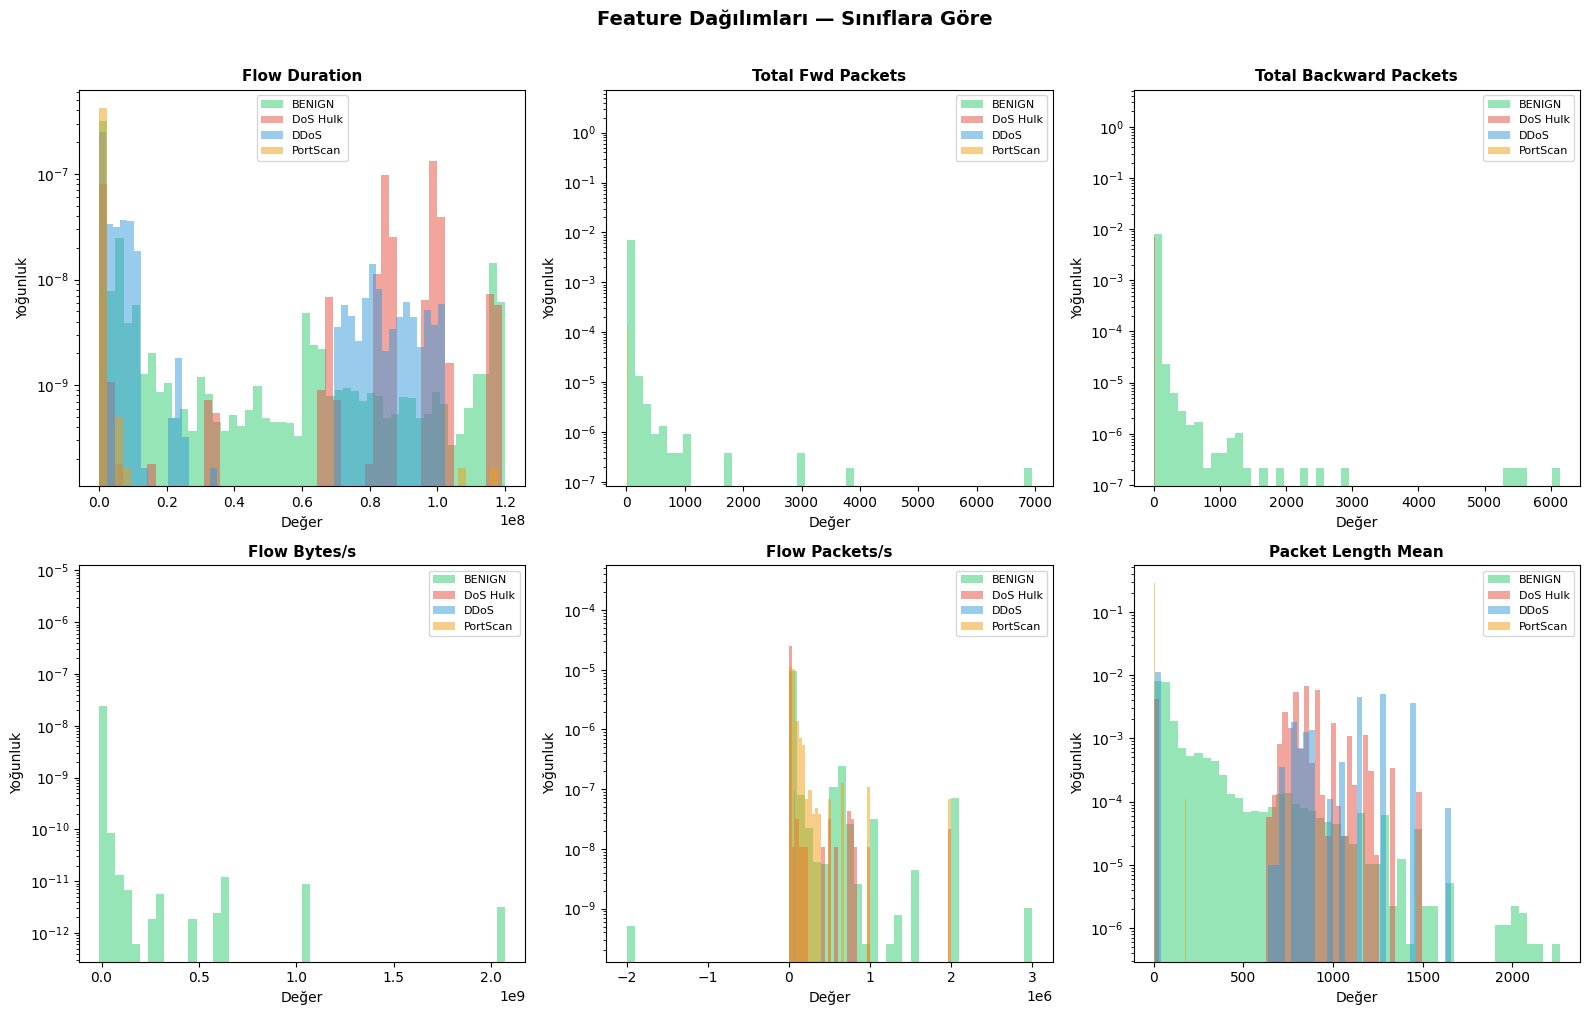

✓ Kaydedildi: ../data/plots/feature_distributions.png


In [3]:
# Sample al — güvenli
df_sample = df.sample(n=min(50000, len(df)), random_state=42)

top_features = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Flow Bytes/s', 'Flow Packets/s', 'Packet Length Mean'
]

# Kullanılacak label'ları kontrol et
plot_labels = ['BENIGN', 'DoS Hulk', 'DDoS', 'PortScan']
plot_labels = [l for l in plot_labels if l in df_sample['Label'].unique()]

colors = {
    'BENIGN': '#2ecc71',
    'DoS Hulk': '#e74c3c',
    'DDoS': '#3498db',
    'PortScan': '#f39c12'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    for label in plot_labels:
        subset = df_sample[df_sample['Label'] == label][feat]
        axes[i].hist(subset, bins=50, alpha=0.5, label=label,
                     color=colors[label], density=True)
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Değer')
    axes[i].set_ylabel('Yoğunluk')
    axes[i].legend(fontsize=8)
    axes[i].set_yscale('log')

plt.suptitle('Feature Dağılımları — Sınıflara Göre', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/plots/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Kaydedildi: ../data/plots/feature_distributions.png")

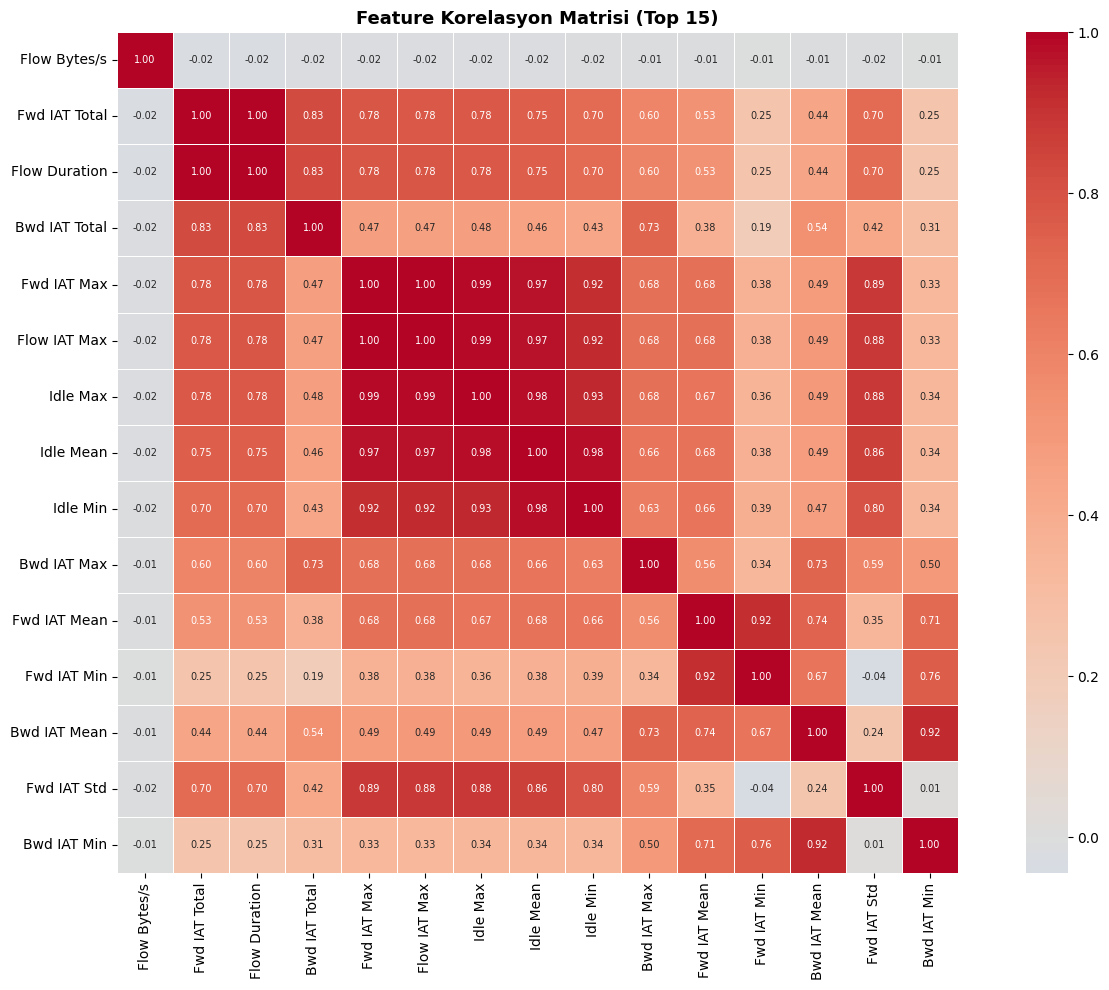

✓ Kaydedildi: ../data/plots/correlation_heatmap.png


In [4]:
# Sample al — güvenli
df_sample = df.sample(n=min(10000, len(df)), random_state=42)

numeric_cols = df_sample.select_dtypes(include=[np.number]).columns.tolist()

# En yüksek varyansa sahip 15 feature
top15 = df_sample[numeric_cols].var().nlargest(15).index.tolist()

corr = df_sample[top15].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 7})

plt.title('Feature Korelasyon Matrisi (Top 15)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/plots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Kaydedildi: ../data/plots/correlation_heatmap.png")

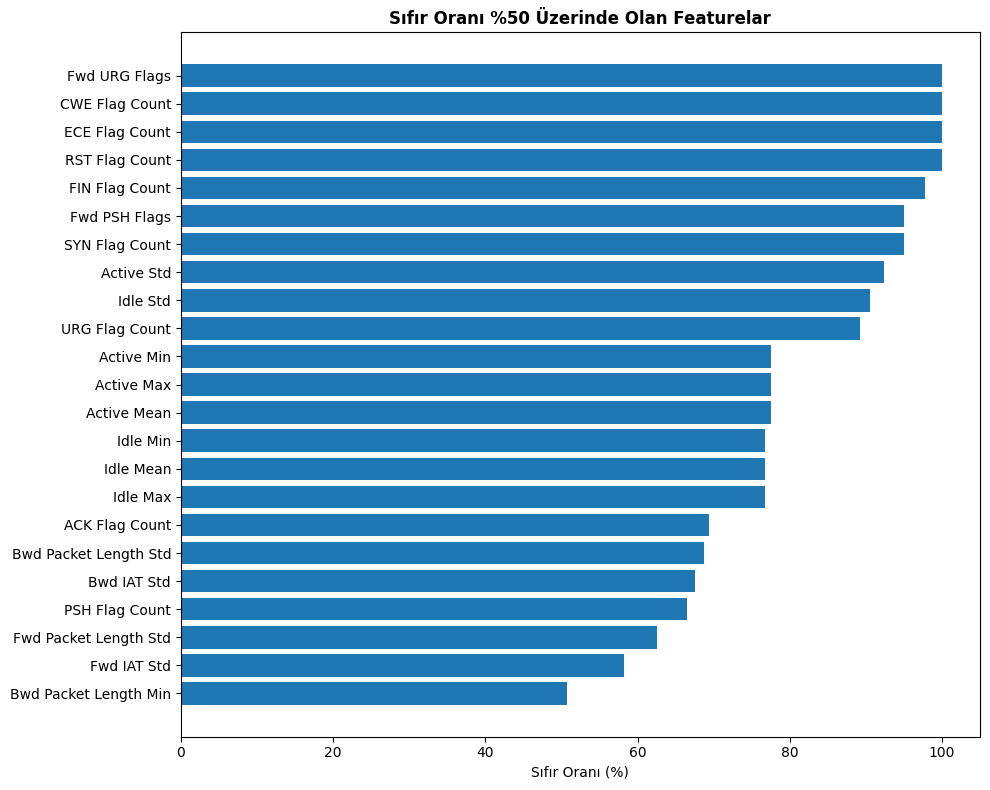

✓ Kaydedildi: ../data/plots/zero_ratio_features.png


In [5]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

zero_pct = (df[numeric_cols] == 0).mean() * 100
sparse_cols = zero_pct[zero_pct > 50].sort_values(ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(sparse_cols.index, sparse_cols.values)

plt.xlabel('Sıfır Oranı (%)')
plt.title('Sıfır Oranı %50 Üzerinde Olan Featurelar', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/plots/zero_ratio_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Kaydedildi: ../data/plots/zero_ratio_features.png")